# Introduction Maps for Paute Basin and Study Area

In [5]:
# Shared imports for the full notebook
import unicodedata
from pathlib import Path

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LightSource, LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch, Patch, Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pyproj import Transformer
from rasterio.enums import Resampling
from rasterio.windows import from_bounds
from shapely.geometry import box

def norm_text(value):
    txt = str(value).strip().upper()
    txt = " ".join(txt.split())
    return unicodedata.normalize("NFKD", txt).encode("ascii", "ignore").decode("ascii")

# Keep imports marked as intentionally shared across later cells.
_ = (
    Path,
    ctx,
    gpd,
    plt,
    np,
    rasterio,
    ScalarMappable,
    LightSource,
    LinearSegmentedColormap,
    Normalize,
    Line2D,
    ConnectionPatch,
    Patch,
    Rectangle,
    make_axes_locatable,
    Transformer,
    Resampling,
    from_bounds,
    box,
    norm_text,
)

In [6]:
# Complex multi-panel study area map (memory-safe, muted palette, right-side legend + colorbar)

# Optional subbasin toggles
SHOW_TOMEBAMBA = False
SHOW_YANUNCAY = False
SHOW_ZHURUCAY = False

# Additional boundary paths
cajas_path = r"C:\\Soilgrids\\data\\cajas\\cajas\\WDPA_WDOECM_Jan2026_Public_7913_shp-polygons.shp"
paute_basin_path = r"C:\\Soilgrids\\data\\cuencas\\PauteBasin.gpkg"
cuenca_city_path = r"C:\\Soilgrids\\data\\adm_ecu\\cuenca_ciudad.shp"
presas_path = r"C:\\Soilgrids\\data\\rivers_paute\\presas\\Presas_CRP.shp"

# Try multiple river layers so plotting still works if one file is missing or empty
river_candidate_paths = [
    r"C:\\Soilgrids\\data\\rivers_paute\\Rios_Dobles_CRP_25k_UTM_SAM56.shp",
    r"C:\\Soilgrids\\data\\rivers_paute\\Rios_CRP_25k_UTM_SAM56.shp",
    r"C:\\Soilgrids\\data\\waterways\\rivers_paute.shp",
]

# Load additional boundaries
try:
    cajas = gpd.read_file(cajas_path)
except Exception:
    cajas = None
    print("Warning: Could not load Cajas shapefile")

try:
    paute_basin = gpd.read_file(paute_basin_path)
except Exception:
    paute_basin = None
    print("Warning: Could not load Paute Basin shapefile")

try:
    cuenca_city = gpd.read_file(cuenca_city_path)
except Exception:
    cuenca_city = None
    print("Warning: Could not load Cuenca city shapefile")

rivers_paute = None
for candidate in river_candidate_paths:
    try:
        candidate_gdf = gpd.read_file(candidate)
        if len(candidate_gdf) > 0:
            rivers_paute = candidate_gdf
            print(f"Using river layer: {candidate}")
            break
    except Exception:
        pass
if rivers_paute is None:
    print("Warning: Could not load any river shapefile")

try:
    presas = gpd.read_file(presas_path)
except Exception:
    presas = None
    print("Warning: Could not load Dams shapefile")

# Reservoir (dam) styling
reservoir_styles = {
    "Mazar": {"color": "#FFD700", "marker": "^", "size": 170},
    "Amaluza (Daniel Palacios)": {"color": "#FFA500", "marker": "s", "size": 165},
}

# -----------------------------
# Paths
# -----------------------------
ecuador_path = r"C:\\Galapagos_IERSE\\01_Organizacion_Territorial\\geoBoundaries-ECU-ADM0.shp"
dem_ecu_path = r"C:\\Soilgrids\\data\\dems\\dem_30m_ecuador_clipped.tif"
tomebamba_path = r"C:\\Soilgrids\\data\\cuencas\\Tomebamba.shp"
yanuncay_path = r"C:\\Soilgrids\\data\\cuencas\\Yanuncay.shp"
zhurucay_path = r"C:\\Soilgrids\\data\\zhurucay\\ZQ9.shp"

# -----------------------------
# Load vector layers
# -----------------------------
ecuador = gpd.read_file(ecuador_path)
tomebamba = gpd.read_file(tomebamba_path) if SHOW_TOMEBAMBA else None
yanuncay = gpd.read_file(yanuncay_path) if SHOW_YANUNCAY else None
zhurucay = gpd.read_file(zhurucay_path) if SHOW_ZHURUCAY else None

# -----------------------------
# Open DEM and gather metadata
# -----------------------------
with rasterio.open(dem_ecu_path) as src:
    dem_crs = src.crs
    dem_bounds = src.bounds
    dem_nodata = src.nodata
    full_h, full_w = src.height, src.width

# Reproject vectors to DEM CRS
if ecuador.crs != dem_crs:
    ecuador = ecuador.to_crs(dem_crs)
if tomebamba is not None and tomebamba.crs != dem_crs:
    tomebamba = tomebamba.to_crs(dem_crs)
if yanuncay is not None and yanuncay.crs != dem_crs:
    yanuncay = yanuncay.to_crs(dem_crs)
if zhurucay is not None and zhurucay.crs != dem_crs:
    zhurucay = zhurucay.to_crs(dem_crs)

# Reproject additional boundaries to DEM CRS
if cajas is not None and cajas.crs != dem_crs:
    cajas = cajas.to_crs(dem_crs)
if paute_basin is not None and paute_basin.crs != dem_crs:
    paute_basin = paute_basin.to_crs(dem_crs)
if cuenca_city is not None and cuenca_city.crs != dem_crs:
    cuenca_city = cuenca_city.to_crs(dem_crs)
if rivers_paute is not None and rivers_paute.crs != dem_crs:
    rivers_paute = rivers_paute.to_crs(dem_crs)
if presas is not None and presas.crs != dem_crs:
    presas = presas.to_crs(dem_crs)

# Study area envelope fallback
study_geoms = []
if tomebamba is not None and len(tomebamba) > 0:
    study_geoms.append(tomebamba.union_all())
if yanuncay is not None and len(yanuncay) > 0:
    study_geoms.append(yanuncay.union_all())
if zhurucay is not None and len(zhurucay) > 0:
    study_geoms.append(zhurucay.union_all())

if len(study_geoms) == 0:
    raise ValueError("No subbasins selected. Set at least one of SHOW_TOMEBAMBA/SHOW_YANUNCAY/SHOW_ZHURUCAY to True.")

study_union = gpd.GeoSeries(study_geoms, crs=dem_crs).union_all()
sx0, sy0, sx1, sy1 = study_union.bounds

# Focus the zoom on the full set of visible boundaries when available
if paute_basin is not None and len(paute_basin) > 0:
    fx0, fy0, fx1, fy1 = paute_basin.total_bounds
else:
    # Fallback to study area union if Paute Basin didn't load
    fx0, fy0, fx1, fy1 = sx0, sy0, sx1, sy1

span_x = fx1 - fx0
span_y = fy1 - fy0

zoom_bounds = (
    fx0 - (0.05 * span_x),
    fy0 - (0.05 * span_y),
    fx1 + (0.05 * span_x),
    fy1 + (0.05 * span_y),
)

# -----------------------------
# Muted elevation colormap
# -----------------------------
muted_elev_cmap = LinearSegmentedColormap.from_list(
    "muted_elev",
    [
        "#2f4a5a",
        "#5f7d78",
        "#9eb3a6",
        "#d8d2be",
        "#b49a7a",
        "#8f765c",
        "#6d5a4a",
    ],
)

# -----------------------------
# Read DEM overview at lower resolution
# -----------------------------
max_dim = 2600
scale = max(full_h / max_dim, full_w / max_dim, 1)
ov_h = int(full_h / scale)
ov_w = int(full_w / scale)

with rasterio.open(dem_ecu_path) as src:
    dem_overview = src.read(
        1,
        out_shape=(ov_h, ov_w),
        resampling=Resampling.bilinear,
    ).astype("float32")

if dem_nodata is not None:
    dem_overview[dem_overview == dem_nodata] = np.nan

extent_ec = [dem_bounds.left, dem_bounds.right, dem_bounds.bottom, dem_bounds.top]
ls1 = LightSource(azdeg=315, altdeg=42)
rgb_ec = ls1.shade(dem_overview, cmap=muted_elev_cmap, blend_mode="soft", vert_exag=0.7)

# -----------------------------
# Read DEM zoom window at moderate resolution
# -----------------------------
with rasterio.open(dem_ecu_path) as src:
    win = from_bounds(*zoom_bounds, transform=src.transform)
    win = win.round_offsets().round_lengths()

    z_h = int(min(win.height, 2200))
    z_w = int(min(win.width, 2200))
    if z_h <= 0 or z_w <= 0:
        z_h, z_w = int(win.height), int(win.width)

    dem_zoom = src.read(
        1,
        window=win,
        out_shape=(z_h, z_w),
        resampling=Resampling.bilinear,
    ).astype("float32")

    if src.nodata is not None:
        dem_zoom[dem_zoom == src.nodata] = np.nan

extent_zoom = [zoom_bounds[0], zoom_bounds[2], zoom_bounds[1], zoom_bounds[3]]

ls2 = LightSource(azdeg=320, altdeg=45)
rgb_zoom = ls2.shade(dem_zoom, cmap=muted_elev_cmap, blend_mode="overlay", vert_exag=1.0)

# Robust color normalization for a filled colorbar
valid_vals = dem_zoom[np.isfinite(dem_zoom)]
vmin = np.nanpercentile(valid_vals, 2)
vmax = np.nanpercentile(valid_vals, 98)
norm = Normalize(vmin=vmin, vmax=vmax)

# -----------------------------
# Figure layout
# -----------------------------
fig = plt.figure(figsize=(13, 14), facecolor="white")
gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[1, 1.38],
    width_ratios=[1, 2],
    hspace=0.14,
    wspace=0.06,
)

ax_sa = fig.add_subplot(gs[0, 0])
ax_ec = fig.add_subplot(gs[0, 1])
ax_zoom = fig.add_subplot(gs[1, :])

# -----------------------------
# Panel A: Americas context + Ecuador highlight
# -----------------------------
ax_sa.set_xlim(-100, -30)
ax_sa.set_ylim(-60, 18)
ctx.add_basemap(
    ax_sa,
    crs="EPSG:4326",
    source=ctx.providers.CartoDB.Positron,
    zoom=3,
    attribution=False,
)

ecu_4326 = ecuador.to_crs("EPSG:4326")
ecu_4326.plot(ax=ax_sa, color="#5693d8", edgecolor="#435c38", linewidth=1.2, zorder=3)

ax_sa.set_title("A  Ecuador in the Americas", loc="left", fontsize=11, fontweight="bold")
ax_sa.set_xticks([])
ax_sa.set_yticks([])
for s in ax_sa.spines.values():
    s.set_visible(False)

# -----------------------------
# Panel B: Ecuador DEM + study area box
# -----------------------------
ax_ec.imshow(rgb_ec, extent=extent_ec, origin="upper", zorder=1)
ecuador.boundary.plot(ax=ax_ec, color="#9db89a", linewidth=1.3, zorder=3)

zoom_rect = Rectangle(
    (zoom_bounds[0], zoom_bounds[1]),
    zoom_bounds[2] - zoom_bounds[0],
    zoom_bounds[3] - zoom_bounds[1],
    fill=False,
    edgecolor="#626262",
    linewidth=1.2,
    zorder=5,
)
ax_ec.add_patch(zoom_rect)

ax_ec.set_xlim(dem_bounds.left, dem_bounds.right)
ax_ec.set_ylim(dem_bounds.bottom, dem_bounds.top)
ax_ec.set_title("B  Ecuador Elevation (DEM)", loc="left", fontsize=11, fontweight="bold")
ax_ec.set_xlabel("Longitude")
ax_ec.set_ylabel("Latitude")
ax_ec.grid(True, linestyle=":", linewidth=0.55, color="#8a8a8a", alpha=0.35)

# -----------------------------
# Panel C: Paute basin close-up
# -----------------------------
ax_zoom.imshow(rgb_zoom, extent=extent_zoom, origin="upper", zorder=1)

# Paute Basin
if paute_basin is not None:
    paute_basin.plot(ax=ax_zoom, facecolor="none", edgecolor="none", zorder=3)
    paute_basin.boundary.plot(ax=ax_zoom, color="#0a0a0a", linewidth=2.2, zorder=4)
    paute_basin.boundary.plot(ax=ax_zoom, color="#000000", linewidth=1.2, linestyle="--", zorder=5)

# Rivers (some datasets are polygons; render boundaries so they appear as linework)
if rivers_paute is not None and len(rivers_paute) > 0:
    view_box = gpd.GeoDataFrame(geometry=[box(zoom_bounds[0], zoom_bounds[1], zoom_bounds[2], zoom_bounds[3])], crs=dem_crs)
    rivers_view = gpd.clip(rivers_paute, view_box)
    if len(rivers_view) > 0:
        is_poly = rivers_view.geom_type.isin(["Polygon", "MultiPolygon"]).any()
        river_draw = rivers_view.boundary if is_poly else rivers_view
        river_draw.plot(ax=ax_zoom, color="#DDE8F2", linewidth=4.0, alpha=0.92, zorder=5)
        river_draw.plot(ax=ax_zoom, color="#3A5F7D", linewidth=1.5, alpha=0.95, zorder=6)
        river_draw.plot(ax=ax_zoom, color="#6F9FBF", linewidth=1.5, alpha=1.0, zorder=7)
    else:
        print("Warning: River layer loaded but no features intersect current map extent")

# Cajas
if cajas is not None:
    cajas.plot(ax=ax_zoom, facecolor="#00C853", edgecolor="none", alpha=0.18, zorder=6)
    cajas.boundary.plot(ax=ax_zoom, color="#1a1a1a", linewidth=3.0, zorder=8)
    cajas.boundary.plot(ax=ax_zoom, color="#00E676", linewidth=1.8, zorder=9)

# Cuenca City
if cuenca_city is not None:
    cuenca_city.plot(ax=ax_zoom, facecolor="#FF4081", edgecolor="none", alpha=0.25, zorder=7)
    cuenca_city.boundary.plot(ax=ax_zoom, color="#1a1a1a", linewidth=2.5, zorder=9)
    cuenca_city.boundary.plot(ax=ax_zoom, color="#FF80AB", linewidth=1.5, zorder=10)

# Optional subbasin overlays
TOM_COLOR = "#D4D102"
YAN_COLOR = "#CF0000"
ZHU_COLOR = "#2E5CF5"
subbasin_styles = []
if tomebamba is not None and len(tomebamba) > 0:
    subbasin_styles.append((tomebamba, TOM_COLOR, "Tomebamba subbasin"))
if yanuncay is not None and len(yanuncay) > 0:
    subbasin_styles.append((yanuncay, YAN_COLOR, "Yanuncay subbasin"))
if zhurucay is not None and len(zhurucay) > 0:
    subbasin_styles.append((zhurucay, ZHU_COLOR, "Zhurucay Observatory basin"))

for gdf, color, _ in subbasin_styles:
    gdf.plot(ax=ax_zoom, facecolor=color, edgecolor="none", alpha=0.28, zorder=10)
    gdf.boundary.plot(ax=ax_zoom, color="#ffffff", linewidth=3.7, zorder=11)
    gdf.boundary.plot(ax=ax_zoom, color="#1f1f1f", linewidth=2.7, zorder=12)
    gdf.boundary.plot(ax=ax_zoom, color=color, linewidth=1.8, zorder=13)

# Dams: larger and with white halo for contrast
if presas is not None:
    for _, row in presas.iterrows():
        name = row.get("Nombre", "Unknown")
        style = reservoir_styles.get(name)
        if style is not None:
            ax_zoom.plot(
                row.geometry.x,
                row.geometry.y,
                marker=style["marker"],
                markerfacecolor="white",
                markeredgecolor="black",
                markeredgewidth=1.3,
                markersize=16,
                zorder=14,
            )
            ax_zoom.plot(
                row.geometry.x,
                row.geometry.y,
                marker=style["marker"],
                color=style["color"],
                markeredgecolor="black",
                markeredgewidth=0.9,
                markersize=13,
                zorder=15,
            )

ax_zoom.set_xlim(zoom_bounds[0], zoom_bounds[2])
ax_zoom.set_ylim(zoom_bounds[1], zoom_bounds[3])
ax_zoom.set_title(
    "C  Paute Basin with Study Areas and Dams",
    loc="left",
    fontsize=11,
    fontweight="bold",
    pad=6,
)
ax_zoom.set_xlabel("Longitude")
ax_zoom.set_ylabel("Latitude")
ax_zoom.grid(True, linestyle=":", linewidth=0.55, color="#8a8a8a", alpha=0.35)

# Connectors between panel B and panel C
con1 = ConnectionPatch(
    xyA=(zoom_bounds[0], zoom_bounds[1]), coordsA=ax_ec.transData,
    xyB=(extent_zoom[0], extent_zoom[3]), coordsB=ax_zoom.transData,
    color="#777777", linestyle="--", linewidth=1.0, zorder=10,
)
con2 = ConnectionPatch(
    xyA=(zoom_bounds[2], zoom_bounds[1]), coordsA=ax_ec.transData,
    xyB=(extent_zoom[1], extent_zoom[3]), coordsB=ax_zoom.transData,
    color="#777777", linestyle="--", linewidth=1.0, zorder=10,
)
fig.add_artist(con1)
fig.add_artist(con2)

# Reserve right margin and increase gap below main title
fig.subplots_adjust(right=0.82, top=0.92, bottom=0.06)

# Colorbar in dedicated side axis
sm = ScalarMappable(norm=norm, cmap=muted_elev_cmap)
sm.set_array([])
cax = fig.add_axes([0.845, 0.22, 0.03, 0.58])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Elevation (m a.s.l.)")

# Legend
legend_lines = [
    Line2D([0], [0], color="#000000", lw=2.0, label="Paute River Basin"),
    Line2D([0], [0], color="#6F9FBF", lw=2.2, label="Rivers (Paute)"),
    Patch(edgecolor="#00E676", facecolor="#00C853", linewidth=1.8, alpha=0.18, label="Cajas National Park"),
    Patch(edgecolor="#FF80AB", facecolor="#FF4081", linewidth=1.5, alpha=0.25, label="Cuenca City"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#FFD700", markeredgecolor="black", markersize=10, label="Mazar Dam"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#FFA500", markeredgecolor="black", markersize=10, label="Amaluza Dam"),
]

# Append enabled subbasins to legend
for _, color, label in subbasin_styles:
    legend_lines.insert(0, Line2D([0], [0], color=color, lw=2.5, label=label))

fig.legend(
    handles=legend_lines,
    loc="lower left",
    bbox_to_anchor=(0.835, 0.02),
    frameon=True,
    framealpha=0.92,
    fontsize=9,
)

fig.suptitle("Study Area Location and Topographic Context", fontsize=15, fontweight="bold", y=0.985)
plt.show()


RasterioIOError: 'C:\\Soilgrids\\data\\dems\\dem_30m_ecuador_clipped.tif' does not exist in the file system, and is not recognized as a supported dataset name.

Climate label field used: PISO_BIOCL


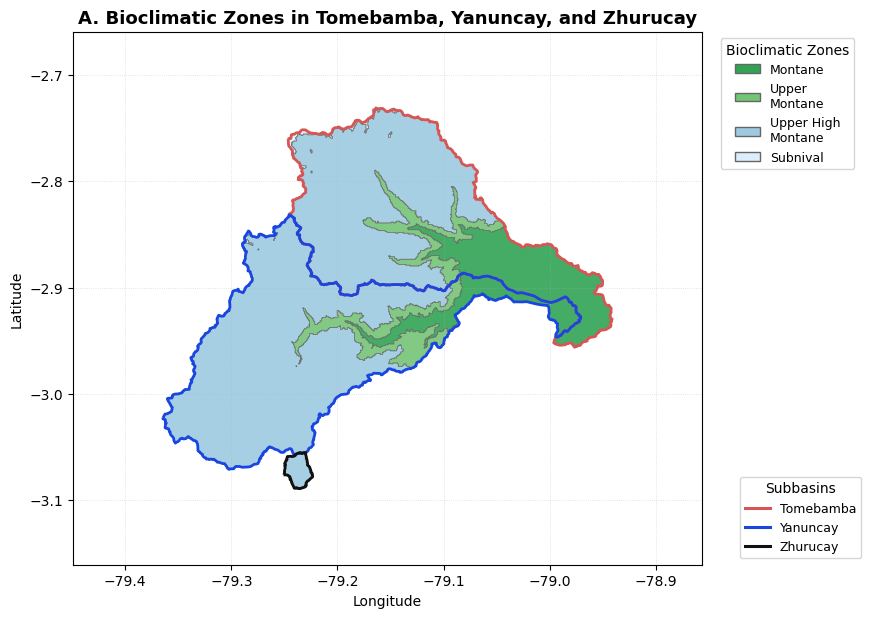

In [9]:
# Map bioclimatic zones for Tomebamba, Yanuncay, and Zhurucay

# Paths
climate_path = r"C:\Soilgrids\Pisos Bioclimaticos_Azuay\Pisos_bioclimaticos_Azuay_MAE_2013.shp"
tomebamba_path = r"C:\Soilgrids\data\cuencas\Tomebamba.shp"
yanuncay_path = r"C:\Soilgrids\data\cuencas\Yanuncay.shp"
zhurucay_path = r"C:\Soilgrids\data\zhurucay\ZQ9.shp"

# Load layers
climate = gpd.read_file(climate_path)
tomebamba = gpd.read_file(tomebamba_path)
yanuncay = gpd.read_file(yanuncay_path)
zhurucay = gpd.read_file(zhurucay_path)

# Reproject to climate CRS for clipping
if tomebamba.crs != climate.crs:
    tomebamba = tomebamba.to_crs(climate.crs)
if yanuncay.crs != climate.crs:
    yanuncay = yanuncay.to_crs(climate.crs)
if zhurucay.crs != climate.crs:
    zhurucay = zhurucay.to_crs(climate.crs)

# Combined analysis area
study_area = gpd.GeoDataFrame(
    geometry=[tomebamba.union_all(), yanuncay.union_all(), zhurucay.union_all()],
    crs=climate.crs,
)

# Clip climate zones to the study area
climate_clip = gpd.clip(climate, study_area)

# Find climate label field
label_field = "PISO_BIOCL" if "PISO_BIOCL" in climate_clip.columns else None
if label_field is None:
    object_cols = [c for c in climate_clip.columns if c != "geometry" and climate_clip[c].dtype == "object"]
    label_field = object_cols[0] if object_cols else climate_clip.columns[0]

print(f"Climate label field used: {label_field}")

# Stable category order
zones = sorted([str(z) for z in climate_clip[label_field].dropna().unique()])

# Explicit color mapping for the known PISO_BIOCL classes
climate_palette = {
    "SUBNIVAL": "#dceefb",
    "MONTANO ALTO SUPERIOR": "#9ecae1",
    "MONTANO ALTO": "#74c476",
    "MONTANO": "#31a354",
    "MONTANO BAJO": "#addd8e",
    "PIEMONTANO": "#fdae6b",
    "TIERRAS BAJAS": "#fdd0a2",
}

# English translation of bioclimatic zones (wrapped to avoid clipping)
zone_english = {
    "SUBNIVAL": "Subnival",
    "MONTANO ALTO SUPERIOR": "Upper High\nMontane",
    "MONTANO ALTO": "Upper\nMontane",
    "MONTANO": "Montane",
    "MONTANO BAJO": "Lower\nMontane",
    "PIEMONTANO": "Piedmont",
    "TIERRAS BAJAS": "Lowlands",
}

# Fallback color if any unexpected class appears
zone_colors = {z: climate_palette.get(z, "#bdbdbd") for z in zones}
climate_clip["plot_color"] = climate_clip[label_field].astype(str).map(zone_colors)

# Reproject to geographic coordinates for lat/lon axes
plot_crs = "EPSG:4326"
climate_plot = climate_clip.to_crs(plot_crs)
tomebamba_plot = tomebamba.to_crs(plot_crs)
yanuncay_plot = yanuncay.to_crs(plot_crs)
zhurucay_plot = zhurucay.to_crs(plot_crs)
study_plot = study_area.to_crs(plot_crs)

# Plot
fig, ax = plt.subplots(figsize=(14.8, 10), facecolor="white")

# Climate polygons
climate_plot.plot(
    ax=ax,
    color=climate_plot["plot_color"],
    edgecolor="#666666",
    linewidth=0.5,
    alpha=0.9,
    zorder=1,
)

# Subbasin outlines
tomebamba_plot.boundary.plot(ax=ax, color="#D65656", linewidth=2.0, zorder=5)
yanuncay_plot.boundary.plot(ax=ax, color="#1846DF", linewidth=2.0, zorder=5)
zhurucay_plot.boundary.plot(ax=ax, color="#111111", linewidth=2.0, zorder=5)

# Fit view to study area with padding
xmin, ymin, xmax, ymax = study_plot.total_bounds
dx = (xmax - xmin) * 0.20
dy = (ymax - ymin) * 0.20
ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(ymin - dy, ymax + dy)

# Legends with English zone names
zone_handles = [
    Patch(facecolor=zone_colors[z], edgecolor="#666666", label=zone_english.get(z, z.title()))
    for z in zones
]
basin_handles = [
    Line2D([0], [0], color="#D65656", lw=2.2, label="Tomebamba"),
    Line2D([0], [0], color="#1846DF", lw=2.2, label="Yanuncay"),
    Line2D([0], [0], color="#111111", lw=2.2, label="Zhurucay"),
]

leg1 = ax.legend(
    handles=zone_handles,
    title="Bioclimatic Zones",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=True,
    fontsize=9,
    title_fontsize=10,
)
ax.add_artist(leg1)

ax.legend(
    handles=basin_handles,
    title="Subbasins",
    loc="lower left",
    bbox_to_anchor=(1.05, 0.0),
    frameon=True,
    fontsize=9,
    title_fontsize=10,
)

ax.set_title("A. Bioclimatic Zones in Tomebamba, Yanuncay, and Zhurucay", fontsize=13, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.45)

# Leave wider space on the right for full legend labels
fig.subplots_adjust(right=0.55)
plt.show()

Available fields: ['objectid', 'fcode', 'ctn1', 'ctn2', 'anio', 'are', 'vuln_score', 'class_en']
Land-use label field used: ctn2
Classes shown in legend: 10


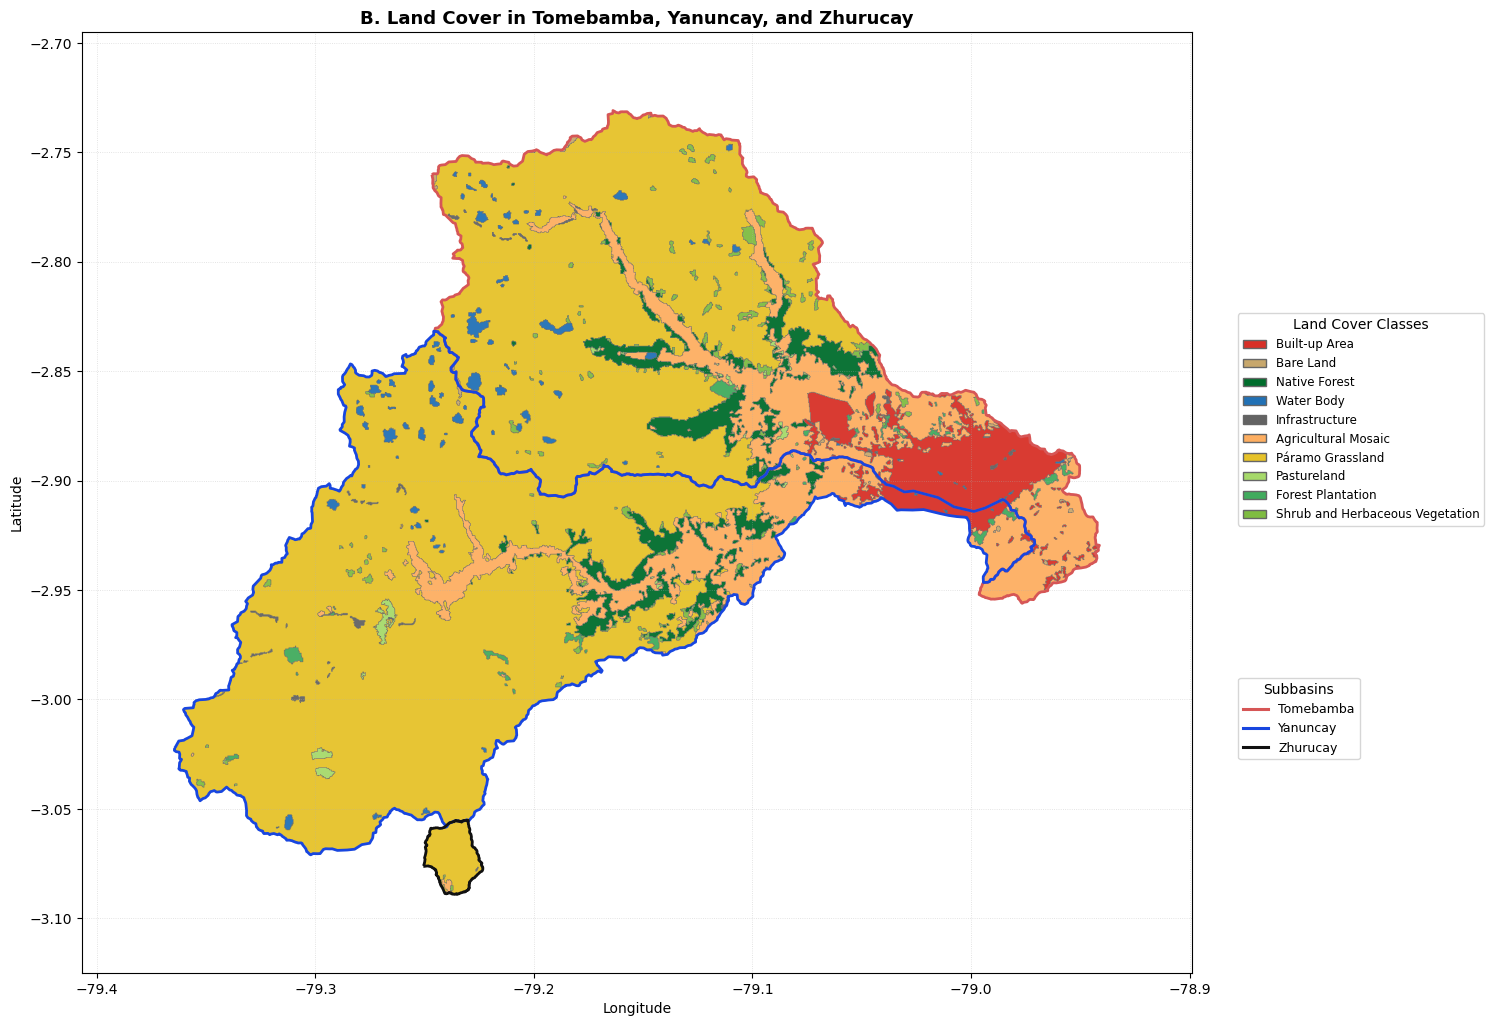

In [10]:
# Land-use map for Tomebamba, Yanuncay, and Zhurucay (from preclipped layer)

# Paths
landuse_clip_path = Path(r"C:\Soilgrids\data\cobertura\landuse_three_subbasins.gpkg")
landuse_clip_layer = "landuse_three_subbasins"
tomebamba_path = r"C:\Soilgrids\data\cuencas\Tomebamba.shp"
yanuncay_path = r"C:\Soilgrids\data\cuencas\Yanuncay.shp"
zhurucay_path = r"C:\Soilgrids\data\zhurucay\ZQ9.shp"

if not landuse_clip_path.exists():
    raise FileNotFoundError(
        f"Missing preclipped file: {landuse_clip_path}. Run Cell 16 first to create it."
    )

# Load preclipped land-use and subbasin outlines
landuse_clip = gpd.read_file(landuse_clip_path, layer=landuse_clip_layer)
tomebamba = gpd.read_file(tomebamba_path)
yanuncay = gpd.read_file(yanuncay_path)
zhurucay = gpd.read_file(zhurucay_path)

# Reproject basins to clipped land-use CRS
if tomebamba.crs != landuse_clip.crs:
    tomebamba = tomebamba.to_crs(landuse_clip.crs)
if yanuncay.crs != landuse_clip.crs:
    yanuncay = yanuncay.to_crs(landuse_clip.crs)
if zhurucay.crs != landuse_clip.crs:
    zhurucay = zhurucay.to_crs(landuse_clip.crs)

# Combined analysis area
study_area = gpd.GeoDataFrame(
    geometry=[tomebamba.union_all(), yanuncay.union_all(), zhurucay.union_all()],
    crs=landuse_clip.crs,
)

# Use known correct land-use attribute
CLASS_FIELD = "ctn2"
if CLASS_FIELD not in landuse_clip.columns:
    raise ValueError(f"Field '{CLASS_FIELD}' not found. Available: {[c for c in landuse_clip.columns if c != 'geometry']}")

# Requested colors (Spanish labels)
landcover_colors = {
    "Área poblada": "#D73027",
    "Área sin cobertura": "#C7A76C",
    "Bosque nativo": "#006D2C",
    "Cuerpo de agua": "#2171B5",
    "Infraestructura": "#636363",
    "Mosaico agropecuario": "#FDAE61",
    "Páramo": "#E6C229",
    "Pastizal": "#A6D96A",
    "Plantación forestal": "#41AB5D",
    "Vegetación arbustiva y herbácea": "#7FBC41",
}

# Requested English class labels (legend order)
classes = [
    "Built-up Area",
    "Bare Land",
    "Native Forest",
    "Water Body",
    "Infrastructure",
    "Agricultural Mosaic",
    "Páramo Grassland",
    "Pastureland",
    "Forest Plantation",
    "Shrub and Herbaceous Vegetation",
]

spanish_order = [
    "Área poblada",
    "Área sin cobertura",
    "Bosque nativo",
    "Cuerpo de agua",
    "Infraestructura",
    "Mosaico agropecuario",
    "Páramo",
    "Pastizal",
    "Plantación forestal",
    "Vegetación arbustiva y herbácea",
]

# Build English color map directly from your Spanish palette
english_colors = {en: landcover_colors[es] for es, en in zip(spanish_order, classes)}

# ctn2 -> requested English classes
ctn2_to_english = {
    "AREA POBLADA": "Built-up Area",
    "AREA SIN COBERTURA VEGETAL": "Bare Land",
    "BOSQUE NATIVO": "Native Forest",
    "CUERPO DE AGUA NATURAL": "Water Body",
    "CUERPO DE AGUA": "Water Body",
    "INFRAESTRUCTURA": "Infrastructure",
    "MOSAICO AGROPECUARIO": "Agricultural Mosaic",
    "PARAMO": "Páramo Grassland",
    "PASTIZAL": "Pastureland",
    "PLANTACION FORESTAL": "Forest Plantation",
    "VEGETACION ARBUSTIVA Y HERBACEA": "Shrub and Herbaceous Vegetation",
}

landuse_clip["class_en"] = landuse_clip[CLASS_FIELD].apply(lambda x: ctn2_to_english.get(norm_text(x), "Other"))

# Keep only requested classes in requested order, plus Other if needed
classes_present = [c for c in classes if c in set(landuse_clip["class_en"])]
if "Other" in set(landuse_clip["class_en"]):
    classes_present.append("Other")
    english_colors["Other"] = "#bdbdbd"

print("Available fields:", [c for c in landuse_clip.columns if c != "geometry"])
print(f"Land-use label field used: {CLASS_FIELD}")
print(f"Classes shown in legend: {len(classes_present)}")

landuse_clip["plot_color"] = landuse_clip["class_en"].map(english_colors)

# Reproject to lat/lon for map display
plot_crs = "EPSG:4326"
landuse_plot = landuse_clip.to_crs(plot_crs)
tomebamba_plot = tomebamba.to_crs(plot_crs)
yanuncay_plot = yanuncay.to_crs(plot_crs)
zhurucay_plot = zhurucay.to_crs(plot_crs)
study_plot = study_area.to_crs(plot_crs)

# Plot — wider figure to accommodate the full legends on the right
fig, ax = plt.subplots(figsize=(20, 13), facecolor="white")

landuse_plot.plot(
    ax=ax,
    color=landuse_plot["plot_color"],
    edgecolor="#666666",
    linewidth=0.30,
    alpha=0.95,
    zorder=1,
)

# Subbasin outlines
tomebamba_plot.boundary.plot(ax=ax, color="#D65656", linewidth=2.0, zorder=5)
yanuncay_plot.boundary.plot(ax=ax, color="#1846DF", linewidth=2.0, zorder=5)
zhurucay_plot.boundary.plot(ax=ax, color="#111111", linewidth=2.0, zorder=5)

# Fit view to study area
xmin, ymin, xmax, ymax = study_plot.total_bounds
dx = (xmax - xmin) * 0.10
dy = (ymax - ymin) * 0.10
ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(ymin - dy, ymax + dy)

ax.set_title("B. Land Cover in Tomebamba, Yanuncay, and Zhurucay", fontsize=13, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.45)

# Reserve right margin for legends BEFORE placing them so they stay inside the figure
fig.subplots_adjust(right=0.68, top=0.94, bottom=0.08)

# Land cover legend — centered on the right side
landuse_handles = [Patch(facecolor=english_colors[c], edgecolor="#666666", label=c) for c in classes_present]
fig.legend(
    handles=landuse_handles,
    title="Land Cover Classes",
    loc="upper left",
    bbox_to_anchor=(0.70, 0.66),
    bbox_transform=fig.transFigure,
    frameon=True,
    fontsize=8.5,
    title_fontsize=10,
)

# Subbasin legend — stacked just below, also centered on the right side
basin_handles = [
    Line2D([0], [0], color="#D65656", lw=2.2, label="Tomebamba"),
    Line2D([0], [0], color="#1846DF", lw=2.2, label="Yanuncay"),
    Line2D([0], [0], color="#111111", lw=2.2, label="Zhurucay"),
]
fig.legend(
    handles=basin_handles,
    title="Subbasins",
    loc="upper left",
    bbox_to_anchor=(0.70, 0.38),
    bbox_transform=fig.transFigure,
    frameon=True,
    fontsize=9,
    title_fontsize=10,
)

plt.show()


Reading precipitation raster...
Precipitation range: 394 - 1948 mm/year


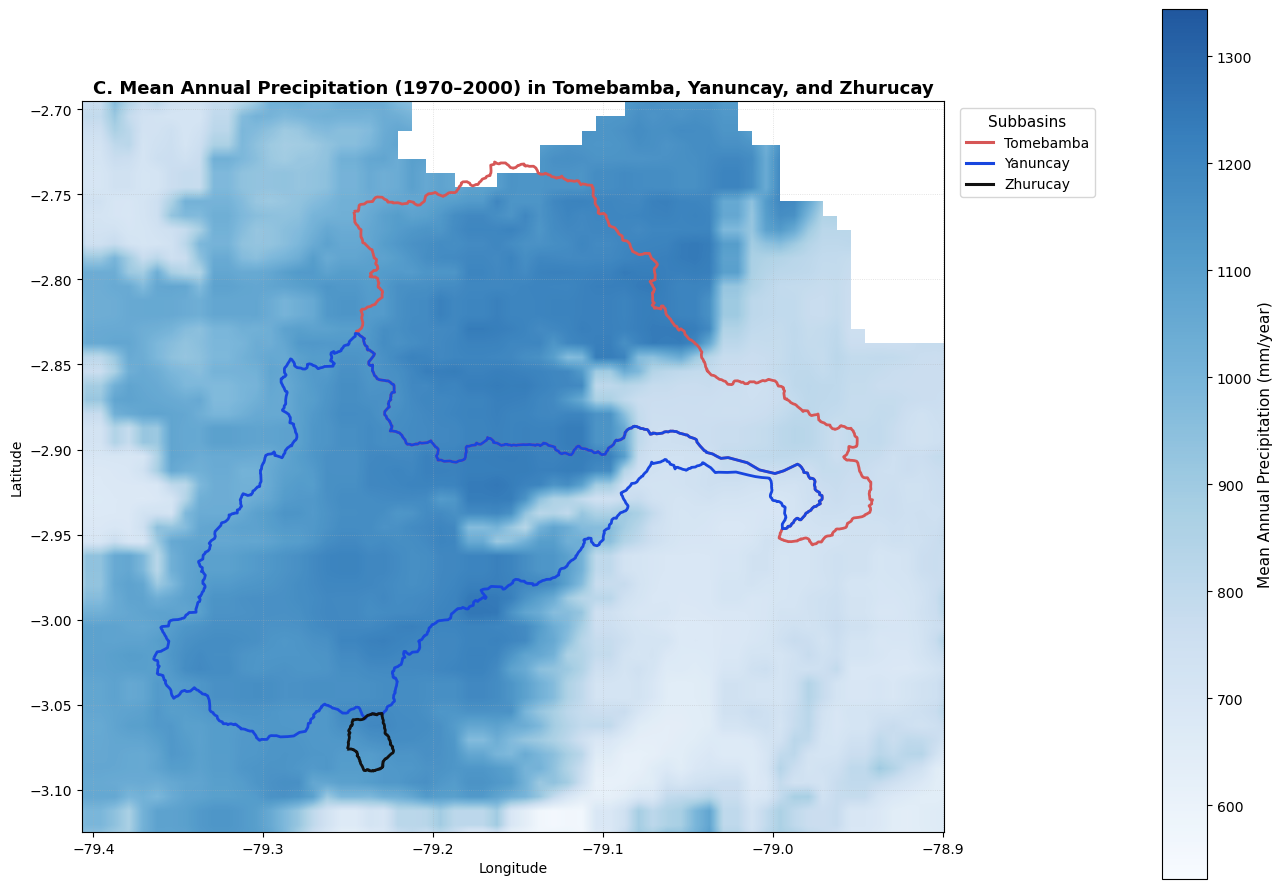

Precipitation data: EPSG:4326


In [11]:
# Precipitation map for Tomebamba, Yanuncay, and Zhurucay

# Paths
precip_path = r"C:\Soilgrids\Precipitacion_1970_2000_Azuay\PCR_PROM_A_1970_2000_AZUAY.tif"
tomebamba_path = r"C:\Soilgrids\data\cuencas\Tomebamba.shp"
yanuncay_path = r"C:\Soilgrids\data\cuencas\Yanuncay.shp"
zhurucay_path = r"C:\Soilgrids\data\zhurucay\ZQ9.shp"

# Load subbasin boundaries
tomebamba = gpd.read_file(tomebamba_path)
yanuncay = gpd.read_file(yanuncay_path)
zhurucay = gpd.read_file(zhurucay_path)

# Open precipitation raster to get CRS
with rasterio.open(precip_path) as src:
    precip_crs = src.crs
    precip_bounds = src.bounds

# Reproject basins to precipitation CRS
if tomebamba.crs != precip_crs:
    tomebamba = tomebamba.to_crs(precip_crs)
if yanuncay.crs != precip_crs:
    yanuncay = yanuncay.to_crs(precip_crs)
if zhurucay.crs != precip_crs:
    zhurucay = zhurucay.to_crs(precip_crs)

# Combined study area
study_area = gpd.GeoDataFrame(
    geometry=[tomebamba.union_all(), yanuncay.union_all(), zhurucay.union_all()],
    crs=precip_crs,
)

# Read precipitation raster at moderate resolution for display
print("Reading precipitation raster...")
with rasterio.open(precip_path) as src:
    # Estimate resolution for memory-efficient reading
    max_dim = 2500
    scale = max(src.height / max_dim, src.width / max_dim, 1)
    
    precip = src.read(
        1,
        out_shape=(int(src.height / scale), int(src.width / scale)),
        resampling=Resampling.bilinear,
    ).astype("float32")

# Mask nodata
precip[precip <= 0] = np.nan
print(f"Precipitation range: {np.nanmin(precip):.0f} - {np.nanmax(precip):.0f} mm/year")

# Custom blue-toned precipitation colormap
precip_cmap = LinearSegmentedColormap.from_list(
    "precip_blue",
    [
        "#f7fbff",  # Very light blue
        "#deebf7",  # Light blue
        "#c6dbef",  # Pale blue
        "#9ecae1",  # Medium-light blue
        "#6baed6",  # Medium blue
        "#4292c6",  # Medium-dark blue
        "#2171b5",  # Dark blue
        "#084594",  # Very dark blue
    ],
)

# Reproject to lat/lon for display
plot_crs = "EPSG:4326"
tomebamba_plot = tomebamba.to_crs(plot_crs)
yanuncay_plot = yanuncay.to_crs(plot_crs)
zhurucay_plot = zhurucay.to_crs(plot_crs)
study_plot = study_area.to_crs(plot_crs)

# Reproject raster extent corners to lat/lon (approximate for visualization)
transformer = Transformer.from_crs(precip_crs, "EPSG:4326", always_xy=True)
lon_min, lat_min = transformer.transform(precip_bounds.left, precip_bounds.bottom)
lon_max, lat_max = transformer.transform(precip_bounds.right, precip_bounds.top)
extent_precip_4326 = [lon_min, lon_max, lat_min, lat_max]

# Plot
fig, ax = plt.subplots(figsize=(15, 15), facecolor="white")

# Normalize precipitation data for colorbar
valid_precip = precip[np.isfinite(precip)]
vmin = np.nanpercentile(valid_precip, 2)
vmax = np.nanpercentile(valid_precip, 98)
norm = Normalize(vmin=vmin, vmax=vmax)

# Display precipitation raster
im = ax.imshow(
    precip,
    extent=extent_precip_4326,
    origin="upper",
    cmap=precip_cmap,
    norm=norm,
    interpolation="bilinear",
    alpha=0.90,
    zorder=1,
)

# Subbasin outlines with high contrast
tomebamba_plot.boundary.plot(ax=ax, color="#D65656", linewidth=2.0, zorder=5, label="Tomebamba")
yanuncay_plot.boundary.plot(ax=ax, color="#1846DF", linewidth=2.0, zorder=5, label="Yanuncay")
zhurucay_plot.boundary.plot(ax=ax, color="#111111", linewidth=2.0, zorder=5, label="Zhurucay")

# Fit view to study area with padding
xmin, ymin, xmax, ymax = study_plot.total_bounds
dx = (xmax - xmin) * 0.10
dy = (ymax - ymin) * 0.10
ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(ymin - dy, ymax + dy)

# Legends
basin_handles = [
    Line2D([0], [0], color="#D65656", lw=2.2, label="Tomebamba"),
    Line2D([0], [0], color="#1846DF", lw=2.2, label="Yanuncay"),
    Line2D([0], [0], color="#111111", lw=2.2, label="Zhurucay"),
]

ax.legend(
    handles=basin_handles,
    title="Subbasins",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    fontsize=10,
    title_fontsize=11,
)

# Colorbar on the right
cax = fig.add_axes([0.845, 0.22, 0.03, 0.58])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Mean Annual Precipitation (mm/year)", fontsize=11)

ax.set_title("C. Mean Annual Precipitation (1970–2000) in Tomebamba, Yanuncay, and Zhurucay",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.45)

# Space for right-side legend and colorbar
fig.subplots_adjust(right=0.7)
plt.show()

print(f"Precipitation data: {precip_crs}")

Reading temperature raster...
Temperature range (NoData removed): 3.9 - 25.2 °C


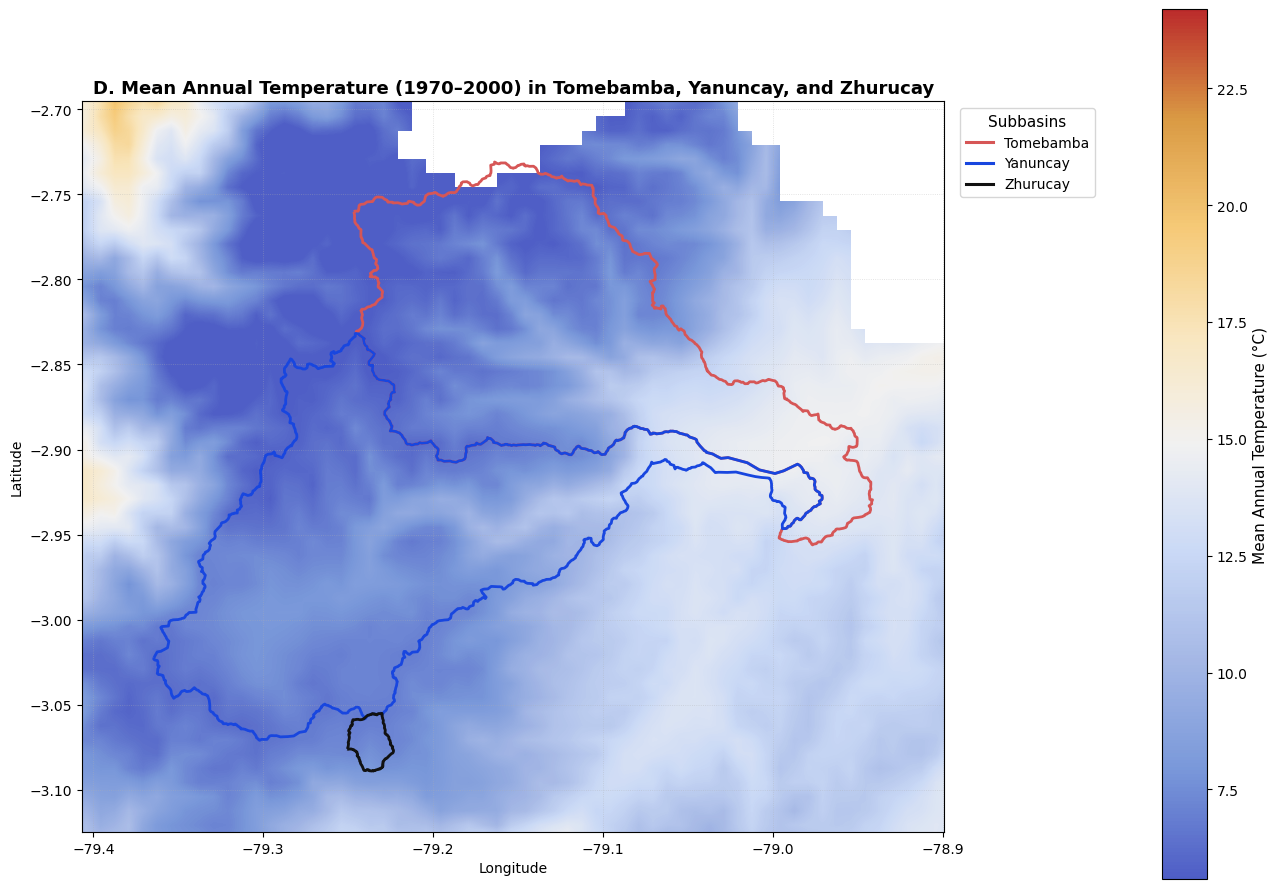

Temperature data: EPSG:4326


In [12]:
# Temperature map for Tomebamba, Yanuncay, and Zhurucay

# Paths
temp_path = r"C:\Soilgrids\Temperatura_1970_2000_Azuay\TMP_PROM_M_1970_2000_AZUAY.tif"
tomebamba_path = r"C:\Soilgrids\data\cuencas\Tomebamba.shp"
yanuncay_path = r"C:\Soilgrids\data\cuencas\Yanuncay.shp"
zhurucay_path = r"C:\Soilgrids\data\zhurucay\ZQ9.shp"

# Load subbasin boundaries
tomebamba = gpd.read_file(tomebamba_path)
yanuncay = gpd.read_file(yanuncay_path)
zhurucay = gpd.read_file(zhurucay_path)

# Open temperature raster to get CRS
with rasterio.open(temp_path) as src:
    temp_crs = src.crs
    temp_bounds = src.bounds

# Reproject basins to temperature CRS
if tomebamba.crs != temp_crs:
    tomebamba = tomebamba.to_crs(temp_crs)
if yanuncay.crs != temp_crs:
    yanuncay = yanuncay.to_crs(temp_crs)
if zhurucay.crs != temp_crs:
    zhurucay = zhurucay.to_crs(temp_crs)

# Combined study area
study_area = gpd.GeoDataFrame(
    geometry=[tomebamba.union_all(), yanuncay.union_all(), zhurucay.union_all()],
    crs=temp_crs,
)

# Read temperature raster at moderate resolution for display
print("Reading temperature raster...")
with rasterio.open(temp_path) as src:
    temp_nodata = src.nodata

    # Estimate resolution for memory-efficient reading
    max_dim = 2500
    scale = max(src.height / max_dim, src.width / max_dim, 1)

    temp = src.read(
        1,
        out_shape=(int(src.height / scale), int(src.width / scale)),
        resampling=Resampling.bilinear,
    ).astype("float32")

# Mask nodata (0 is user-confirmed nodata)
if temp_nodata is not None:
    temp[temp == temp_nodata] = np.nan
temp[temp == 0] = np.nan
temp[temp < -50] = np.nan  # guard against invalid fill values

valid_temp = temp[np.isfinite(temp)]
if valid_temp.size == 0:
    raise ValueError("All temperature values are NoData after masking.")

print(f"Temperature range (NoData removed): {np.nanmin(temp):.1f} - {np.nanmax(temp):.1f} °C")

# Custom warm-to-cool temperature colormap (cold blues to hot reds)
temp_cmap = LinearSegmentedColormap.from_list(
    "temp_diverging",
    [
        "#3b4cc0",  # Cool blue
        "#6b8dd6",  # Light blue
        "#9bb0e3",  # Very light blue
        "#c4d5f5",  # Pale blue
        "#f0f0f0",  # White (neutral)
        "#f9e4b8",  # Pale yellow
        "#f5c468",  # Light yellow
        "#d68f2f",  # Orange
        "#b41414",  # Dark red
    ],
)

# Reproject to lat/lon for display
plot_crs = "EPSG:4326"
tomebamba_plot = tomebamba.to_crs(plot_crs)
yanuncay_plot = yanuncay.to_crs(plot_crs)
zhurucay_plot = zhurucay.to_crs(plot_crs)
study_plot = study_area.to_crs(plot_crs)

# Reproject raster extent corners to lat/lon (approximate for visualization)
transformer = Transformer.from_crs(temp_crs, "EPSG:4326", always_xy=True)
lon_min, lat_min = transformer.transform(temp_bounds.left, temp_bounds.bottom)
lon_max, lat_max = transformer.transform(temp_bounds.right, temp_bounds.top)
extent_temp_4326 = [lon_min, lon_max, lat_min, lat_max]

# Plot
fig, ax = plt.subplots(figsize=(15, 15), facecolor="white")

# Normalize temperature data for colorbar
vmin = np.nanpercentile(valid_temp, 2)
vmax = np.nanpercentile(valid_temp, 98)
norm = Normalize(vmin=vmin, vmax=vmax)

# Display temperature raster
im = ax.imshow(
    temp,
    extent=extent_temp_4326,
    origin="upper",
    cmap=temp_cmap,
    norm=norm,
    interpolation="bilinear",
    alpha=0.90,
    zorder=1,
)

# Subbasin outlines with high contrast
tomebamba_plot.boundary.plot(ax=ax, color="#D65656", linewidth=2.0, zorder=5, label="Tomebamba")
yanuncay_plot.boundary.plot(ax=ax, color="#1846DF", linewidth=2.0, zorder=5, label="Yanuncay")
zhurucay_plot.boundary.plot(ax=ax, color="#111111", linewidth=2.0, zorder=5, label="Zhurucay")

# Fit view to study area with padding
xmin, ymin, xmax, ymax = study_plot.total_bounds
dx = (xmax - xmin) * 0.10
dy = (ymax - ymin) * 0.10
ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(ymin - dy, ymax + dy)

# Legends
basin_handles = [
    Line2D([0], [0], color="#D65656", lw=2.2, label="Tomebamba"),
    Line2D([0], [0], color="#1846DF", lw=2.2, label="Yanuncay"),
    Line2D([0], [0], color="#111111", lw=2.2, label="Zhurucay"),
]

ax.legend(
    handles=basin_handles,
    title="Subbasins",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    fontsize=10,
    title_fontsize=11,
)

# Colorbar on the right
cax = fig.add_axes([0.845, 0.22, 0.03, 0.58])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Mean Annual Temperature (°C)", fontsize=11)

ax.set_title("D. Mean Annual Temperature (1970–2000) in Tomebamba, Yanuncay, and Zhurucay",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.45)

# Space for right-side legend and colorbar
fig.subplots_adjust(right=0.7)
plt.show()

print(f"Temperature data: {temp_crs}")

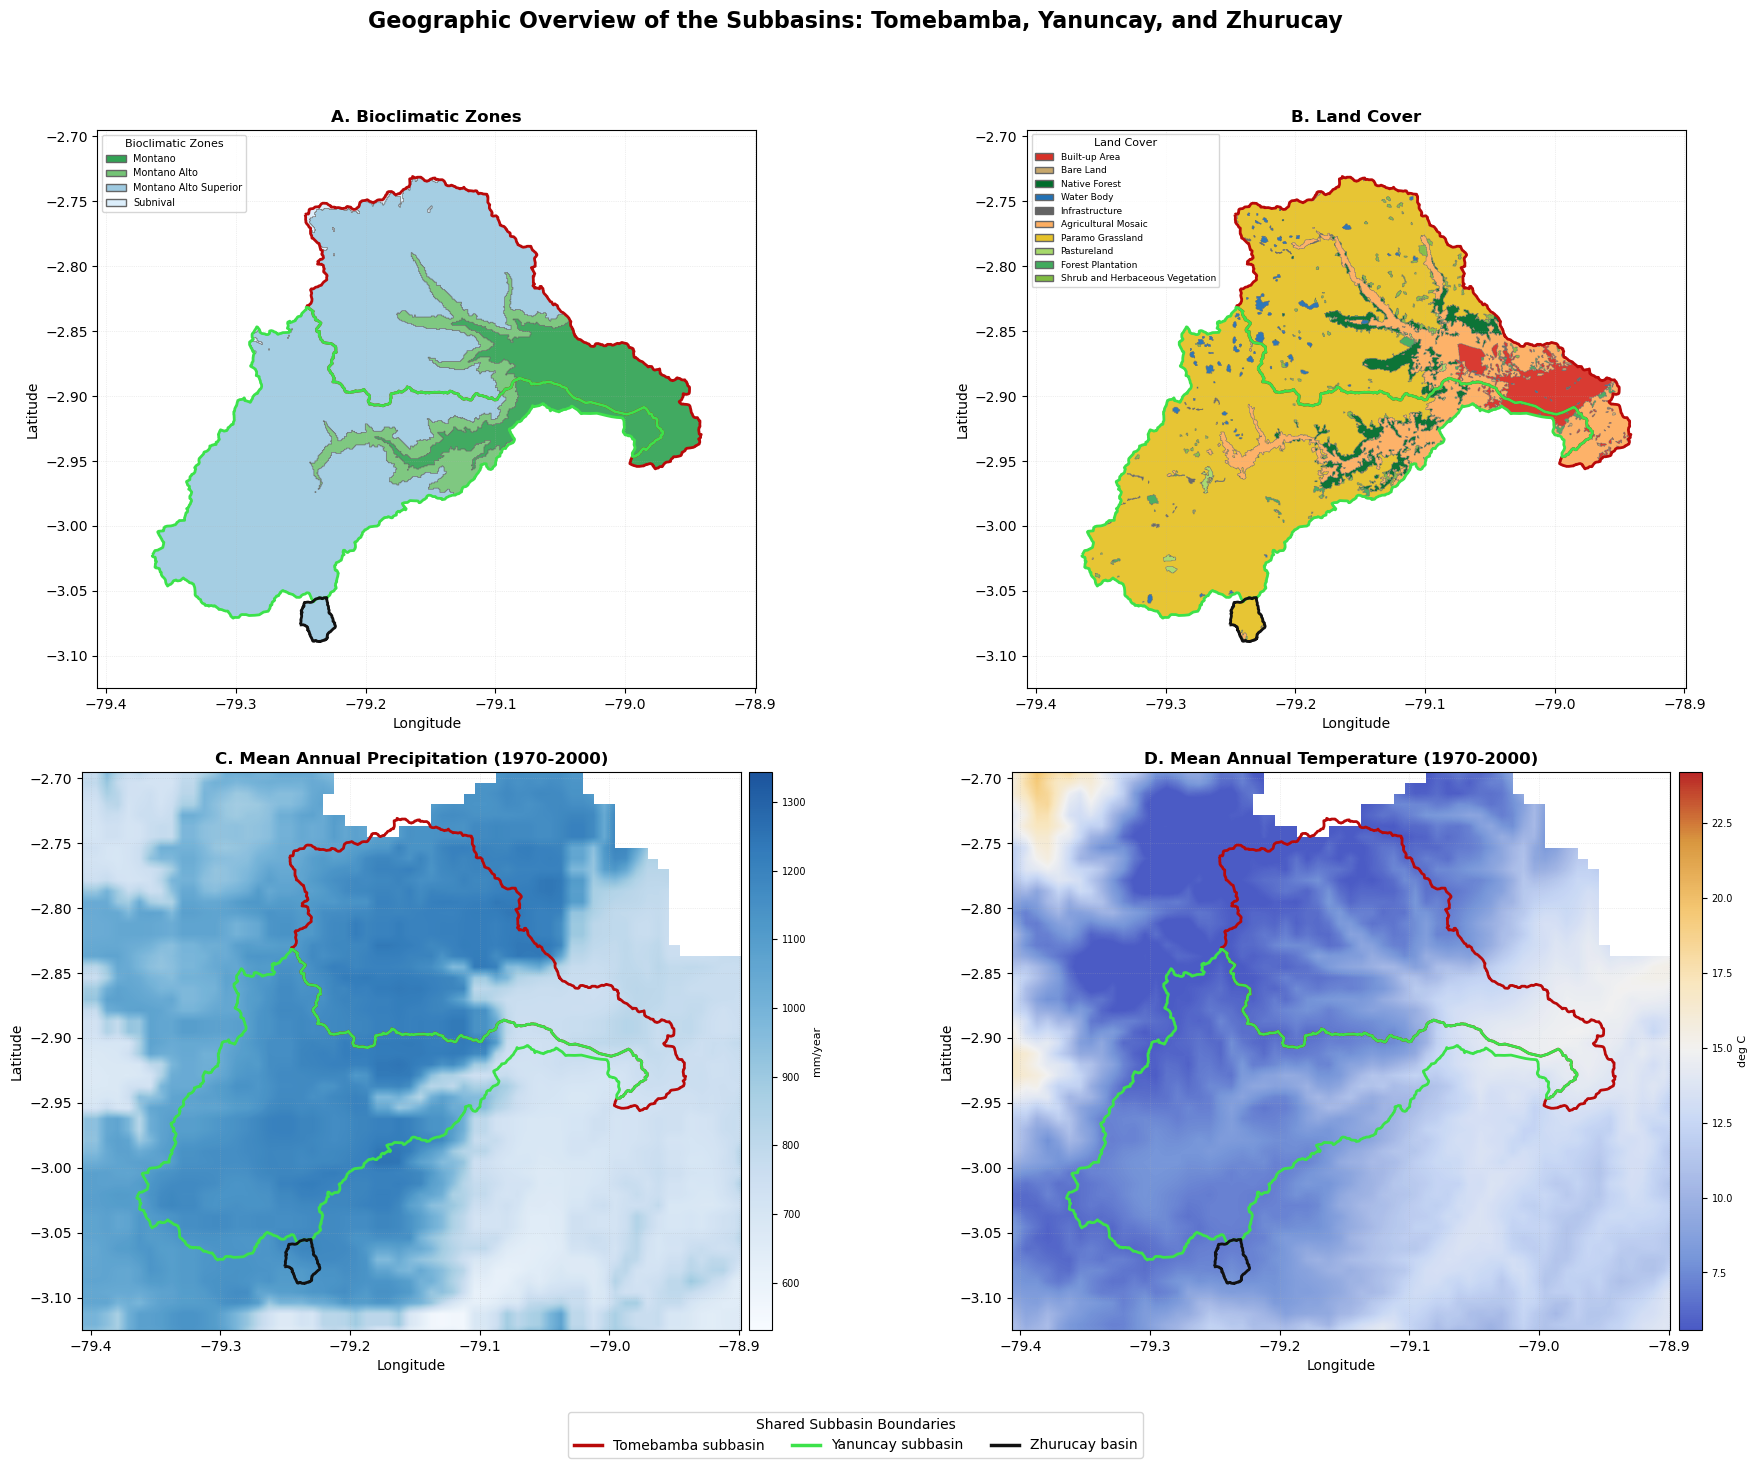

2x2 panel map created successfully.


In [13]:
# 2x2 combined map panel: climate, land cover, precipitation, and temperature

# -----------------------------
# Paths
# -----------------------------
climate_path = r"C:\Soilgrids\Pisos Bioclimaticos_Azuay\Pisos_bioclimaticos_Azuay_MAE_2013.shp"
landuse_path = r"C:\Soilgrids\data\cobertura\landuse_three_subbasins.gpkg"
landuse_layer = "landuse_three_subbasins"
precip_path = r"C:\Soilgrids\Precipitacion_1970_2000_Azuay\PCR_PROM_A_1970_2000_AZUAY.tif"
temp_path = r"C:\Soilgrids\Temperatura_1970_2000_Azuay\TMP_PROM_M_1970_2000_AZUAY.tif"

tomebamba_path = r"C:\Soilgrids\data\cuencas\Tomebamba.shp"
yanuncay_path = r"C:\Soilgrids\data\cuencas\Yanuncay.shp"
zhurucay_path = r"C:\Soilgrids\data\zhurucay\ZQ9.shp"

# -----------------------------
# Load subbasins and prepare shared extent
# -----------------------------
tomebamba = gpd.read_file(tomebamba_path)
yanuncay = gpd.read_file(yanuncay_path)
zhurucay = gpd.read_file(zhurucay_path)

plot_crs = "EPSG:4326"
tomebamba_plot = tomebamba.to_crs(plot_crs)
yanuncay_plot = yanuncay.to_crs(plot_crs)
zhurucay_plot = zhurucay.to_crs(plot_crs)

study_area = gpd.GeoDataFrame(
    geometry=[tomebamba_plot.union_all(), yanuncay_plot.union_all(), zhurucay_plot.union_all()],
    crs=plot_crs,
)

xmin, ymin, xmax, ymax = study_area.total_bounds
dx = (xmax - xmin) * 0.10
dy = (ymax - ymin) * 0.10
xlim = (xmin - dx, xmax + dx)
ylim = (ymin - dy, ymax + dy)

# -----------------------------
# Load climate map data
# -----------------------------
climate = gpd.read_file(climate_path).to_crs(plot_crs)
climate_clip = gpd.clip(climate, study_area)

label_field = "PISO_BIOCL" if "PISO_BIOCL" in climate_clip.columns else None
if label_field is None:
    object_cols = [c for c in climate_clip.columns if c != "geometry" and climate_clip[c].dtype == "object"]
    label_field = object_cols[0] if object_cols else climate_clip.columns[0]

zones = sorted([str(z) for z in climate_clip[label_field].dropna().unique()])
climate_palette = {
    "SUBNIVAL": "#dceefb",
    "MONTANO ALTO SUPERIOR": "#9ecae1",
    "MONTANO ALTO": "#74c476",
    "MONTANO": "#31a354",
    "MONTANO BAJO": "#addd8e",
    "PIEMONTANO": "#fdae6b",
    "TIERRAS BAJAS": "#fdd0a2",
}
zone_colors = {z: climate_palette.get(z, "#bdbdbd") for z in zones}
climate_clip["plot_color"] = climate_clip[label_field].astype(str).map(zone_colors)

# -----------------------------
# Load land-cover map data
# -----------------------------
landuse_clip = gpd.read_file(landuse_path, layer=landuse_layer).to_crs(plot_crs)

CLASS_FIELD = "ctn2"
if CLASS_FIELD not in landuse_clip.columns:
    raise ValueError(f"Field '{CLASS_FIELD}' not found in land-use layer")

classes = [
    "Built-up Area",
    "Bare Land",
    "Native Forest",
    "Water Body",
    "Infrastructure",
    "Agricultural Mosaic",
    "Paramo Grassland",
    "Pastureland",
    "Forest Plantation",
    "Shrub and Herbaceous Vegetation",
]
spanish_order = [
    "Area poblada",
    "Area sin cobertura",
    "Bosque nativo",
    "Cuerpo de agua",
    "Infraestructura",
    "Mosaico agropecuario",
    "Paramo",
    "Pastizal",
    "Plantacion forestal",
    "Vegetacion arbustiva y herbacea",
]
landcover_colors_ascii = {
    "Area poblada": "#D73027",
    "Area sin cobertura": "#C7A76C",
    "Bosque nativo": "#006D2C",
    "Cuerpo de agua": "#2171B5",
    "Infraestructura": "#636363",
    "Mosaico agropecuario": "#FDAE61",
    "Paramo": "#E6C229",
    "Pastizal": "#A6D96A",
    "Plantacion forestal": "#41AB5D",
    "Vegetacion arbustiva y herbacea": "#7FBC41",
}
english_colors = {en: landcover_colors_ascii[es] for es, en in zip(spanish_order, classes)}

ctn2_to_english = {
    "AREA POBLADA": "Built-up Area",
    "AREA SIN COBERTURA VEGETAL": "Bare Land",
    "BOSQUE NATIVO": "Native Forest",
    "CUERPO DE AGUA NATURAL": "Water Body",
    "CUERPO DE AGUA": "Water Body",
    "INFRAESTRUCTURA": "Infrastructure",
    "MOSAICO AGROPECUARIO": "Agricultural Mosaic",
    "PARAMO": "Paramo Grassland",
    "PASTIZAL": "Pastureland",
    "PLANTACION FORESTAL": "Forest Plantation",
    "VEGETACION ARBUSTIVA Y HERBACEA": "Shrub and Herbaceous Vegetation",
}

landuse_clip["class_en"] = landuse_clip[CLASS_FIELD].apply(lambda x: ctn2_to_english.get(norm_text(x), "Other"))
if "Other" in set(landuse_clip["class_en"]):
    english_colors["Other"] = "#bdbdbd"
landuse_clip["plot_color"] = landuse_clip["class_en"].map(english_colors)
classes_present = [c for c in classes if c in set(landuse_clip["class_en"])]
if "Other" in set(landuse_clip["class_en"]):
    classes_present.append("Other")

# -----------------------------
# Load precipitation raster
# -----------------------------
with rasterio.open(precip_path) as src:
    precip = src.read(1).astype("float32")
    precip_bounds = src.bounds
    precip_crs = src.crs
    precip_nodata = src.nodata

if precip_nodata is not None:
    precip[precip == precip_nodata] = np.nan
precip[precip <= 0] = np.nan

precip_tf = Transformer.from_crs(precip_crs, "EPSG:4326", always_xy=True)
pr_lon_min, pr_lat_min = precip_tf.transform(precip_bounds.left, precip_bounds.bottom)
pr_lon_max, pr_lat_max = precip_tf.transform(precip_bounds.right, precip_bounds.top)
precip_extent = [pr_lon_min, pr_lon_max, pr_lat_min, pr_lat_max]

precip_valid = precip[np.isfinite(precip)]
precip_norm = Normalize(
    vmin=np.nanpercentile(precip_valid, 2),
    vmax=np.nanpercentile(precip_valid, 98),
)
precip_cmap = LinearSegmentedColormap.from_list(
    "precip_blue",
    ["#f7fbff", "#deebf7", "#c6dbef", "#9ecae1", "#6baed6", "#4292c6", "#2171b5", "#084594"],
)

# -----------------------------
# Load temperature raster
# -----------------------------
with rasterio.open(temp_path) as src:
    temp = src.read(1).astype("float32")
    temp_bounds = src.bounds
    temp_crs = src.crs
    temp_nodata = src.nodata

if temp_nodata is not None:
    temp[temp == temp_nodata] = np.nan
temp[temp == 0] = np.nan
temp[temp < -50] = np.nan

if np.isfinite(temp).sum() == 0:
    raise ValueError("All temperature values are NoData after masking.")

temp_tf = Transformer.from_crs(temp_crs, "EPSG:4326", always_xy=True)
t_lon_min, t_lat_min = temp_tf.transform(temp_bounds.left, temp_bounds.bottom)
t_lon_max, t_lat_max = temp_tf.transform(temp_bounds.right, temp_bounds.top)
temp_extent = [t_lon_min, t_lon_max, t_lat_min, t_lat_max]

temp_valid = temp[np.isfinite(temp)]
temp_norm = Normalize(
    vmin=np.nanpercentile(temp_valid, 2),
    vmax=np.nanpercentile(temp_valid, 98),
)
temp_cmap = LinearSegmentedColormap.from_list(
    "temp_diverging",
    ["#3b4cc0", "#6b8dd6", "#9bb0e3", "#c4d5f5", "#f0f0f0", "#f9e4b8", "#f5c468", "#d68f2f", "#b41414"],
)

# -----------------------------
# Build 2x2 panel
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 15), facecolor="white")
ax_clim = axes[0, 0]
ax_lu = axes[0, 1]
ax_pr = axes[1, 0]
ax_tm = axes[1, 1]

# 1) Climate
climate_clip.plot(
    ax=ax_clim,
    color=climate_clip["plot_color"],
    edgecolor="#666666",
    linewidth=0.4,
    alpha=0.92,
    zorder=1,
)
for gdf, color in [(tomebamba_plot, "#B90909"), (yanuncay_plot, "#3CE24A"), (zhurucay_plot, "#111111")]:
    gdf.boundary.plot(ax=ax_clim, color=color, linewidth=2.0, zorder=3)
zone_handles = [Patch(facecolor=zone_colors[z], edgecolor="#666666", label=z.title()) for z in zones]
ax_clim.legend(handles=zone_handles, title="Bioclimatic Zones", fontsize=7, title_fontsize=8, loc="upper left", frameon=True)
ax_clim.set_title("A. Bioclimatic Zones", fontsize=12, fontweight="bold")

# 2) Land cover
landuse_clip.plot(
    ax=ax_lu,
    color=landuse_clip["plot_color"],
    edgecolor="#666666",
    linewidth=0.25,
    alpha=0.95,
    zorder=1,
)
for gdf, color in [(tomebamba_plot, "#B90909"), (yanuncay_plot, "#3CE24A"), (zhurucay_plot, "#111111")]:
    gdf.boundary.plot(ax=ax_lu, color=color, linewidth=2.0, zorder=3)
land_handles = [Patch(facecolor=english_colors[c], edgecolor="#666666", label=c) for c in classes_present]
ax_lu.legend(handles=land_handles, title="Land Cover", fontsize=6.5, title_fontsize=8, loc="upper left", frameon=True)
ax_lu.set_title("B. Land Cover", fontsize=12, fontweight="bold")

# 3) Precipitation
im_pr = ax_pr.imshow(
    precip,
    extent=precip_extent,
    origin="upper",
    cmap=precip_cmap,
    norm=precip_norm,
    interpolation="bilinear",
    alpha=0.92,
    zorder=1,
)
for gdf, color in [(tomebamba_plot, "#B90909"), (yanuncay_plot, "#3CE24A"), (zhurucay_plot, "#111111")]:
    gdf.boundary.plot(ax=ax_pr, color=color, linewidth=2.0, zorder=3)
divider_pr = make_axes_locatable(ax_pr)
cax_pr = divider_pr.append_axes("right", size="3.5%", pad=0.08)
cbar_pr = fig.colorbar(im_pr, cax=cax_pr)
cbar_pr.set_label("mm/year", fontsize=8)
cbar_pr.ax.tick_params(labelsize=7)
ax_pr.set_title("C. Mean Annual Precipitation (1970-2000)", fontsize=12, fontweight="bold")

# 4) Temperature
im_tm = ax_tm.imshow(
    temp,
    extent=temp_extent,
    origin="upper",
    cmap=temp_cmap,
    norm=temp_norm,
    interpolation="bilinear",
    alpha=0.92,
    zorder=1,
)
for gdf, color in [(tomebamba_plot, "#B90909"), (yanuncay_plot, "#3CE24A"), (zhurucay_plot, "#111111")]:
    gdf.boundary.plot(ax=ax_tm, color=color, linewidth=2.0, zorder=3)
divider_tm = make_axes_locatable(ax_tm)
cax_tm = divider_tm.append_axes("right", size="3.5%", pad=0.08)
cbar_tm = fig.colorbar(im_tm, cax=cax_tm)
cbar_tm.set_label("deg C", fontsize=8)
cbar_tm.ax.tick_params(labelsize=7)
ax_tm.set_title("D. Mean Annual Temperature (1970-2000)", fontsize=12, fontweight="bold")

# Shared axis formatting
for ax in [ax_clim, ax_lu, ax_pr, ax_tm]:
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)

# Shared bottom legend for subbasin boundaries
shared_basin_handles = [
    Line2D([0], [0], color="#B90909", lw=2.5, label="Tomebamba subbasin"),
    Line2D([0], [0], color="#3CE24A", lw=2.5, label="Yanuncay subbasin"),
    Line2D([0], [0], color="#111111", lw=2.5, label="Zhurucay basin"),
]
fig.legend(
    handles=shared_basin_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.01),
    title="Shared Subbasin Boundaries",
)

fig.suptitle("Geographic Overview of the Subbasins: Tomebamba, Yanuncay, and Zhurucay", fontsize=16, fontweight="bold", y=0.98)
fig.subplots_adjust(left=0.06, right=0.98, top=0.90, bottom=0.10, wspace=0.28, hspace=0.15)
plt.show()

print("2x2 panel map created successfully.")